# 2.0 Ttest — TVLA 누설 진단 · Normal ∥ Masked

## 이 노트북이 답하는 질문

**"이 구현에서 비밀에 의존하는 누설이 관측되는가?"**

`scalib.metrics.Ttest`는 두 집단의 Trace(트레이스)가 통계적으로 다른지를 Sample(샘플)마다 검정한다.
키를 복구하지 않는다 — **진단**이지 공격이 아니다.

| | |
|---|---|
| 입력 | 타겟별 `/tvla_rk` (랜덤 키 1,000장), `/tvla_fk` (고정 키 1,000장) — **평문은 두 집단 모두 동일 고정** |
| 하드웨어 | 불필요. `1.0.SNR` 선행 필요 (`enc_start` 를 쓴다) |

## 시나리오

| 집단 | 키 | 평문 | 라벨 |
|------|----|------|:----:|
| 0 | 트레이스마다 **랜덤** | 고정 | 0 |
| 1 | **고정** | 같은 고정 평문 | 1 |

평문이 양쪽 모두 같으므로, 두 집단의 차이는 오직 **키가 고정인가 아닌가** 에서 온다.
비보호 구현이라면 키에 의존하는 중간값이 그대로 전력에 실리므로 차이가 나타난다.

## 이 노트북의 함정 — 먼저 읽을 것

이 시나리오를 **Trace 전 구간**에 그대로 적용하면 Normal과 Masked가 거의 같은 $|t|$를 낸다.
그 수치만 보고 "마스킹이 소용없다" 고 결론 내리기 쉽다. **그것은 틀린 해석이다.**

`my_crypt.c` 의 `MY_AES_ECB` 는 트리거 구간 안에서 `AES_init_ctx`(=`KeyExpansion`)를 먼저
부르는데, `masked-aes-c` 의 키 스케줄은 **벤더 원본 그대로 비마스킹**이다. 마스킹은
`CipherMasked` 안에서만 적용된다. 즉 Trace 앞부분은 두 타겟이 동일하게 무방비이고,
"키가 고정인가 랜덤인가" 를 묻는 이 검정은 바로 그 구간에서 가장 크게 반응한다.

그래서 이 노트북은 **전 구간과 암호화 구간(`enc_start` 이후)을 둘 다** 잰다.
전자는 함정을 보여 주기 위해, 후자는 마스킹이 실제로 하는 일을 보기 위해.

## Welch t-test

시점 $j$ 에서

$$ t_j = \frac{\mu_{0,j} - \mu_{1,j}}{\sqrt{\dfrac{v_{0,j}}{n_0} + \dfrac{v_{1,j}}{n_1}}} $$

- $|t|$ 가 크다 = 두 집단의 평균이 우연이라고 보기 어려울 만큼 벌어져 있다
- 관례 경보선은 **±4.5**. 넘으면 "추가 조사 대상" 이지 **불합격 판정이 아니다**

## 차수

| 차수 | 보는 것 |
|:----:|---------|
| 1차 | 평균의 차이 |
| 2차 | 중심화 후 제곱의 평균 차이 — 평균이 같아도 **분산**이 다르면 잡힌다 |

`Ttest(d=2)` 는 둘을 한 번에 계산한다. 마스킹은 1차 평균을 눌러도 2차 통계는 남길 수 있으므로
두 차수를 같이 본다.

---
## 1. `Ttest` API

| 단계 | 코드 |
|:----:|------|
| 생성 | `tt = Ttest(d=2)` |
| 누적 | `tt.fit_u(traces, x)` — 집단마다 한 번씩 불러도 되고, 합쳐서 한 번에 넣어도 된다 |
| 결과 | `tt.get_ttest()` → `(d, ns)` |

> **라벨 shape 규약이 API 마다 다르다.** 문서에 정리되어 있지 않고 실행해 봐야 알 수 있어
> 여기 적어 둔다. 틀리면 `ValueError: The classes array has N dimensions` 가 난다.
>
> | API | 라벨 shape | dtype |
> |-----|-----------|-------|
> | `Ttest` | `(n,)` | `uint16` |
> | `SNR`, `Cpa`, `MultiLDA` | `(n, nv)` | `uint16` |
> | `LDAClassifier` | `(n,)` | `uint16` |
> | `RLDAClassifier` | `(n, nv)` | `uint64` |
> | `RLDAInformationEstimator` | `(n,)` | `uint64` |
>
> Trace(`traces`)는 어디서나 `(n, ns)` `int16`이다.

`Ttest` 의 라벨은 **1차원**이고 값은 **0 또는 1만** 쓴다. 그 밖의 정수는 shape 검사를
통과해도 내부에서 비정상 종료할 수 있다.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.family"] = "NanumGothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from scalib_common import (
    TARGETS, TARGET_IDS, load_group, load_poi, dataset_summary, require_target,
)
from scalib.metrics import Ttest

THR = 4.5

tvals, enc_start = {}, {}
for tid in TARGET_IDS:
    if not require_target(tid)["dataset"].is_file():
        print("[%s] 데이터셋 없음 — skip" % TARGETS[tid]["short"]); continue
    rk = load_group("tvla_rk", target=tid)
    fk = load_group("tvla_fk", target=tid)
    enc_start[tid] = int(load_poi(tid)["enc_start"])

    tt = Ttest(d=2)
    tt.fit_u(np.ascontiguousarray(rk["t"]), np.zeros(len(rk["t"]), dtype=np.uint16))
    tt.fit_u(np.ascontiguousarray(fk["t"]), np.ones(len(fk["t"]), dtype=np.uint16))
    tvals[tid] = tt.get_ttest()          # (2, ns)
    print("[%s] rk%s fk%s → t%s  enc_start=%d" % (
        TARGETS[tid]["short"], rk["t"].shape, fk["t"].shape,
        tvals[tid].shape, enc_start[tid]))

if not tvals:
    raise FileNotFoundError("데이터셋이 없다.")

[Normal] rk(1000, 33172) fk(1000, 33172) → t(2, 33172)  enc_start=5093


[Masked] rk(1000, 55184) fk(1000, 55184) → t(2, 55184)  enc_start=5089


---
## 2. 전 구간 — 함정을 눈으로 본다

먼저 Trace 전체로 계산한다. 여기서 두 타겟의 숫자가 비슷하게 나오는 것이 이 노트북의 출발점이다.

In [2]:
print("%-8s %6s %12s %14s" % ("타겟", "차수", "max |t|", "임계 초과 샘플"))
for tid, tv in tvals.items():
    for d_i in range(tv.shape[0]):
        v = np.abs(tv[d_i])
        print("%-8s %6d %12.2f %14d" % (
            TARGETS[tid]["short"], d_i + 1, np.nanmax(v), int(np.sum(v > THR))))
    print()

print("전 구간만 보면 Normal 과 Masked 의 1차 max|t| 가 비슷하다.")
print("이것만으로 '마스킹이 소용없다' 고 결론 내리면 안 된다 — 3절에서 어디서 나오는지 본다.")

타겟           차수      max |t|       임계 초과 샘플
Normal        1       114.31          15662
Normal        2        15.40           6190

Masked        1       113.81           8271
Masked        2        15.54           2431

전 구간만 보면 Normal 과 Masked 의 1차 max|t| 가 비슷하다.
이것만으로 '마스킹이 소용없다' 고 결론 내리면 안 된다 — 3절에서 어디서 나오는지 본다.


---
## 3. 어디서 새는가 — 키 스케줄 vs 암호화

$|t|$ 곡선을 그리고 `enc_start`(1.0 이 구한 암호화 시작점)로 나눠 본다.

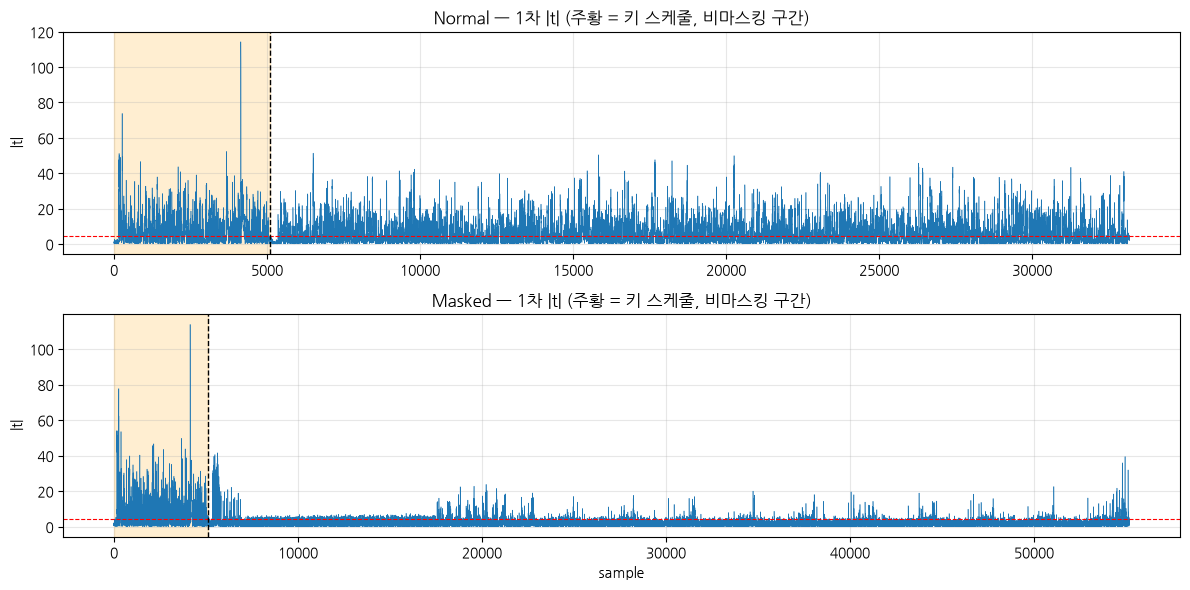

타겟           차수      키스케줄 max       암호화 max      KS 초과율       암호화 초과율
Normal        1        114.31         51.35       57.8%         45.3%
Normal        2         15.40         15.10       26.5%         17.2%

Masked        1        113.81         41.54       61.7%         10.2%
Masked        2         14.77         15.54       36.5%          1.1%



In [3]:
fig, axes = plt.subplots(len(tvals), 1, figsize=(12, 3.0 * len(tvals)))
if len(tvals) == 1:
    axes = [axes]
for ax, tid in zip(axes, tvals):
    v = np.abs(tvals[tid][0])
    lo = enc_start[tid]
    ax.plot(v, lw=0.4, color="C0")
    ax.axhline(THR, color="r", ls="--", lw=0.8)
    ax.axvspan(0, lo, color="orange", alpha=0.18)
    ax.axvline(lo, color="k", ls="--", lw=1.0)
    ax.set_title("%s — 1차 |t| (주황 = 키 스케줄, 비마스킹 구간)"
                 % TARGETS[tid]["short"])
    ax.set_ylabel("|t|"); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("sample")
fig.tight_layout(); plt.show()

print("%-8s %6s %13s %13s %11s %13s" % (
    "타겟", "차수", "키스케줄 max", "암호화 max", "KS 초과율", "암호화 초과율"))
summary = {}
for tid, tv in tvals.items():
    lo = enc_start[tid]
    for d_i in range(tv.shape[0]):
        v = np.abs(tv[d_i])
        ks, enc = v[:lo], v[lo:]
        # 두 타겟은 파형 길이가 다르다. 초과 '개수' 를 그대로 비교하면 길이 차이가
        # 섞이므로, 구간 길이로 나눈 **비율**을 본다.
        summary[(tid, d_i)] = (float(np.nanmax(ks)), float(np.nanmax(enc)),
                               float(np.mean(ks > THR)) * 100,
                               float(np.mean(enc > THR)) * 100)
        print("%-8s %6d %13.2f %13.2f %10.1f%% %12.1f%%" % (
            (TARGETS[tid]["short"], d_i + 1) + summary[(tid, d_i)]))
    print()

### 읽는 법

- **키 스케줄 구간(주황)**: 두 타겟 모두 크게 반응한다. `KeyExpansion` 이 양쪽 다 비마스킹이므로
  당연하다. 여기서 나온 $|t|$ 는 마스킹의 성능과 아무 관계가 없다.
- **암호화 구간**: 여기가 실제 비교 지점이다. 두 지표를 같이 본다.
  - **max$|t|$** — 가장 심하게 새는 한 지점의 세기.
  - **초과율** — 구간 Sample 중 임계를 넘는 비율. 두 타겟의 Trace 길이가 다르므로
    개수가 아니라 비율로 봐야 한다. 누설이 **얼마나 넓게 퍼져 있는가** 를 말해 준다.

  마스킹이 봉우리 하나를 못 없애도 범위를 크게 줄일 수 있다. 그 경우 max 만 보면
  차이가 없어 보이고 초과율에서 드러난다.
- **2차**: 1차가 눌려도 2차가 남을 수 있다. 마스킹이 "없애는" 것이 아니라 "차수를 올리는"
  방어이기 때문이다. 더 정밀한 조합 검정은 2.1 MTtest 에서 한다.

In [4]:
if len(tvals) == 2:
    print("=== 암호화 구간 비교 (enc_start 이후) ===")
    for d_i in (0, 1):
        n_max, m_max = summary[("tiny-AES-c", d_i)][1], summary[("masked-aes-c", d_i)][1]
        n_pct, m_pct = summary[("tiny-AES-c", d_i)][3], summary[("masked-aes-c", d_i)][3]
        print("%d차  max|t|   Normal %8.2f  vs  Masked %8.2f   (비 %.2f)"
              % (d_i + 1, n_max, m_max, m_max / n_max if n_max else float("nan")))
        print("     초과율   Normal %7.1f%%  vs  Masked %7.1f%%   (%.0f배 차이)"
              % (n_pct, m_pct, n_pct / m_pct if m_pct else float("inf")))
    print()
    n1_pct = summary[("tiny-AES-c", 0)][3]
    m1_pct = summary[("masked-aes-c", 0)][3]
    print("최댓값만 보면 차이가 작아 보인다 — 봉우리 하나는 남아 있다는 뜻이다.")
    print("차이가 뚜렷한 것은 **누설이 퍼진 범위**다: 암호화 구간에서 임계를 넘는 샘플이")
    print("Normal 은 %.1f%%, Masked 는 %.1f%% 다." % (n1_pct, m1_pct))
    print("Normal 은 라운드 연산 내내 새고, Masked 는 몇 지점에만 남았다.")
    print()
    print("→ 마스킹은 암호화 구간의 1차 누설을 대부분 없앴지만 완전히는 아니다.")
    print("  남은 봉우리는 2.1 에서 특정 t-test 로 더 정밀하게 본다.")

=== 암호화 구간 비교 (enc_start 이후) ===
1차  max|t|   Normal    51.35  vs  Masked    41.54   (비 0.81)
     초과율   Normal    45.3%  vs  Masked    10.2%   (4배 차이)
2차  max|t|   Normal    15.10  vs  Masked    15.54   (비 1.03)
     초과율   Normal    17.2%  vs  Masked     1.1%   (15배 차이)

최댓값만 보면 차이가 작아 보인다 — 봉우리 하나는 남아 있다는 뜻이다.
차이가 뚜렷한 것은 **누설이 퍼진 범위**다: 암호화 구간에서 임계를 넘는 샘플이
Normal 은 45.3%, Masked 는 10.2% 다.
Normal 은 라운드 연산 내내 새고, Masked 는 몇 지점에만 남았다.

→ 마스킹은 암호화 구간의 1차 누설을 대부분 없앴지만 완전히는 아니다.
  남은 봉우리는 2.1 에서 특정 t-test 로 더 정밀하게 본다.


---
## 4. 몇 장이면 충분한가

$|t|$ 는 트레이스 수가 늘면 커진다(분모의 표준오차가 $1/\sqrt{n}$ 로 줄기 때문).
따라서 **"몇 장에서 잰 $|t|$ 인가" 를 빼고 값만 말하는 것은 의미가 없다.**

여기서는 암호화 구간만 놓고 트레이스 수를 늘려 가며 잰다.

In [5]:
print("%-8s %8s %12s %12s" % ("타겟", "장수", "1차 max|t|", "2차 max|t|"))
for tid in tvals:
    rk = load_group("tvla_rk", target=tid)
    fk = load_group("tvla_fk", target=tid)
    lo = enc_start[tid]
    for m in (100, 250, 500, 1000):
        m = min(m, len(rk["t"]), len(fk["t"]))
        tt = Ttest(d=2)
        tt.fit_u(np.ascontiguousarray(rk["t"][:m]), np.zeros(m, dtype=np.uint16))
        tt.fit_u(np.ascontiguousarray(fk["t"][:m]), np.ones(m, dtype=np.uint16))
        v = np.abs(tt.get_ttest())[:, lo:]
        print("%-8s %8d %12.2f %12.2f" % (
            TARGETS[tid]["short"], m, np.nanmax(v[0]), np.nanmax(v[1])))
    print()

타겟             장수    1차 max|t|    2차 max|t|
Normal        100        18.87         5.86
Normal        250        25.92         8.51
Normal        500        37.69        12.22


Normal       1000        51.35        15.10



Masked        100        15.75         6.77
Masked        250        24.26         9.00
Masked        500        29.71        11.43
Masked       1000        41.54        15.54



### 주의 — `argmax` 위치는 안정적이지 않다

누설이 넓게 퍼져 있으면 최댓값을 내는 **위치**는 측정 잡음에 따라 바뀐다.
같은 장비·같은 배선에서 다시 재도 옮겨 다닌다. 비교할 때는 위치가 아니라
**크기**와 **임계 초과 지점 수**를 본다.

---
## 5. 요약

| 항목 | 내용 |
|------|------|
| 목적 | 두 집단 Trace의 차이로 **누설 유무를 진단**한다(키 복구 아님) |
| API | `Ttest(d)` → `fit_u(traces, x)` → `get_ttest()` → `(d, ns)` |
| `x` | `(n,)` `uint16`, 값은 **0/1만** |
| 임계 | \|t\|=4.5 는 관례 경보선. 넘으면 조사 대상이지 불합격 판정이 아니다 |
| 비교 기준 | max\|t\| **크기**와 임계 초과 지점 수. **argmax 위치는 쓰지 않는다** |
| 이 노트북의 요점 | **구간을 나누지 않으면 마스킹 평가가 불가능하다** |

### 결론 — 벤더 구현에 대해

`masked-aes-c` 는 `CipherMasked` 만 보호하고 `KeyExpansion` 은 원본 비마스킹을 그대로 쓴다.
그리고 이 저장소의 펌웨어는 키 스케줄을 트리거 **안**에서 수행한다.
따라서 이 Dataset(데이터셋)에서:

- 전 구간 TVLA 는 **마스킹 평가에 쓸 수 없다.** 키 스케줄 누설이 지배한다.
- 마스킹의 효과는 **암호화 구간에서만** 판정해야 한다.
- 실제 제품이라면 키 스케줄도 보호 대상이다. 이 PoC 의 보호 범위가 좁은 것이지,
  마스킹이라는 대책 자체의 한계가 아니다.

### 실패 시 점검

1. 두 집단의 평문이 다르면 t 가 "키 차이" 가 아니라 "평문 차이" 를 가리킨다.
2. 집단 간 측정 조건(게인·트리거·Trace 길이)이 다르면 그 차이가 그대로 t 로 나온다.
3. `|t|` 가 전 구간에서 작다 → 트레이스 수를 늘려 본다. 그래도 작으면 이 시나리오에서는
   관측되지 않는 것이며, **안전하다는 증명은 아니다.**

다음: `2.1.MTtest.ipynb` — 한 시점이 아니라 시점 **조합**을 보는 검정.